<a href="https://colab.research.google.com/github/rubenzito/localidadespalhmento/blob/main/Medidas_de_Espalhamento.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Sepal length - dados concentrados
---------------------------------
Mínimo    : 4.30
Máximo    : 7.90
Intervalo : 3.60
Média     : 5.84

Petal length - dados espalhados
-------------------------------
Mínimo    : 1.00
Máximo    : 6.90
Intervalo : 5.90
Média     : 3.76


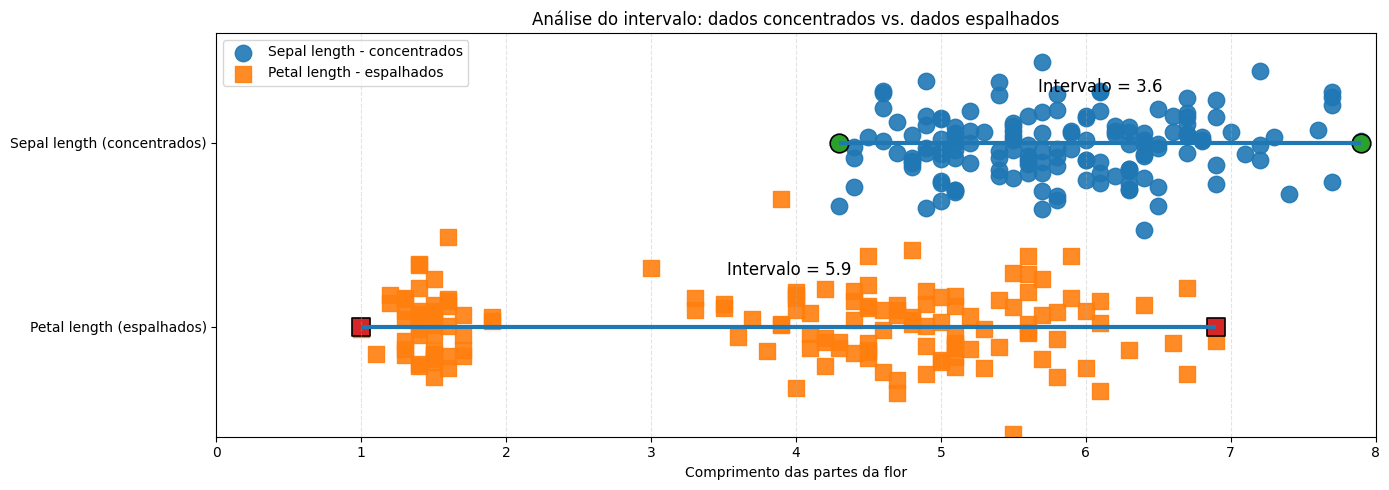

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ============================================================
# EXEMPLO: ANÁLISE DO INTERVALO COM DADOS CONCENTRADOS
#          E DADOS ESPALHADOS
#
# Aplicação adaptada:
# Comprimento de partes da flor na base Iris.
# ============================================================

np.random.seed(42)

# ------------------------------------------------------------
# 1. Geração sintética dos dados
# ------------------------------------------------------------
# Leitura da base Iris
csv_url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(csv_url)

# Dados da base: comprimento da parte verde da flor
tamanhos_concentrados = df["sepal_length"]

# Dados da base: comprimento da pétala
tamanhos_espalhados = df["petal_length"]

# ------------------------------------------------------------
# 2. Função para resumir a análise do intervalo
# ------------------------------------------------------------
def resumo_intervalo(nome, dados):
    minimo = np.min(dados)
    maximo = np.max(dados)
    intervalo = maximo - minimo
    media = np.mean(dados)

    print(f"\n{nome}")
    print("-" * len(nome))
    print(f"Mínimo    : {minimo:.2f}")
    print(f"Máximo    : {maximo:.2f}")
    print(f"Intervalo : {intervalo:.2f}")
    print(f"Média     : {media:.2f}")

# Exibe os resumos
resumo_intervalo("Sepal length - dados concentrados", tamanhos_concentrados)
resumo_intervalo("Petal length - dados espalhados", tamanhos_espalhados)

# ------------------------------------------------------------
# 3. Preparação do gráfico
# ------------------------------------------------------------
# Pequena dispersão vertical apenas para visualização
y_concentrados = np.random.normal(loc=1.0, scale=0.18, size=len(tamanhos_concentrados))
y_espalhados = np.random.normal(loc=0.0, scale=0.18, size=len(tamanhos_espalhados))

min_conc, max_conc = np.min(tamanhos_concentrados), np.max(tamanhos_concentrados)
min_esp, max_esp = np.min(tamanhos_espalhados), np.max(tamanhos_espalhados)

range_conc = max_conc - min_conc
range_esp = max_esp - min_esp

# ------------------------------------------------------------
# 4. Plot semelhante ao da figura
# ------------------------------------------------------------
plt.figure(figsize=(14, 5))

# Pontos
plt.scatter(tamanhos_concentrados, y_concentrados, s=140, alpha=0.9, label="Sepal length - concentrados")
plt.scatter(tamanhos_espalhados, y_espalhados, s=140, marker="s", alpha=0.9, label="Petal length - espalhados")

# Linhas horizontais indicando o intervalo
plt.hlines(y=1.0, xmin=min_conc, xmax=max_conc, linewidth=3)
plt.hlines(y=0.0, xmin=min_esp, xmax=max_esp, linewidth=3)

# Marca mínimo e máximo
plt.scatter([min_conc, max_conc], [1.0, 1.0], s=180, edgecolors="black", linewidths=1.2)
plt.scatter([min_esp, max_esp], [0.0, 0.0], s=180, marker="s", edgecolors="black", linewidths=1.2)

# Anotações dos intervalos
plt.text((min_conc + max_conc) / 2, 1.28, f"Intervalo = {range_conc:.1f}",
         ha="center", fontsize=12)
plt.text((min_esp + max_esp) / 2, 0.28, f"Intervalo = {range_esp:.1f}",
         ha="center", fontsize=12)

# Eixos e rótulos
plt.yticks([0, 1], ["Petal length (espalhados)", "Sepal length (concentrados)"])
plt.xlabel("Comprimento das partes da flor")
plt.title("Análise do intervalo: dados concentrados vs. dados espalhados")
plt.xlim(0, 8)
plt.ylim(-0.6, 1.6)
plt.grid(axis="x", linestyle="--", alpha=0.35)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()


Sem outliers
------------
Número de observações : 150
Média                 : 3.76
Variância             : 3.12
Desvio padrão         : 1.77

Com outliers
------------
Número de observações : 153
Média                 : 3.80
Variância             : 3.39
Desvio padrão         : 1.84

INTERPRETAÇÃO
A variância é mais sensível a valores extremos.
O desvio padrão é a raiz quadrada da variância.
Como os outliers aumentam os desvios em relação à média, as duas medidas crescem.
Isso mostra como valores extremos afetam a dispersão dos dados.


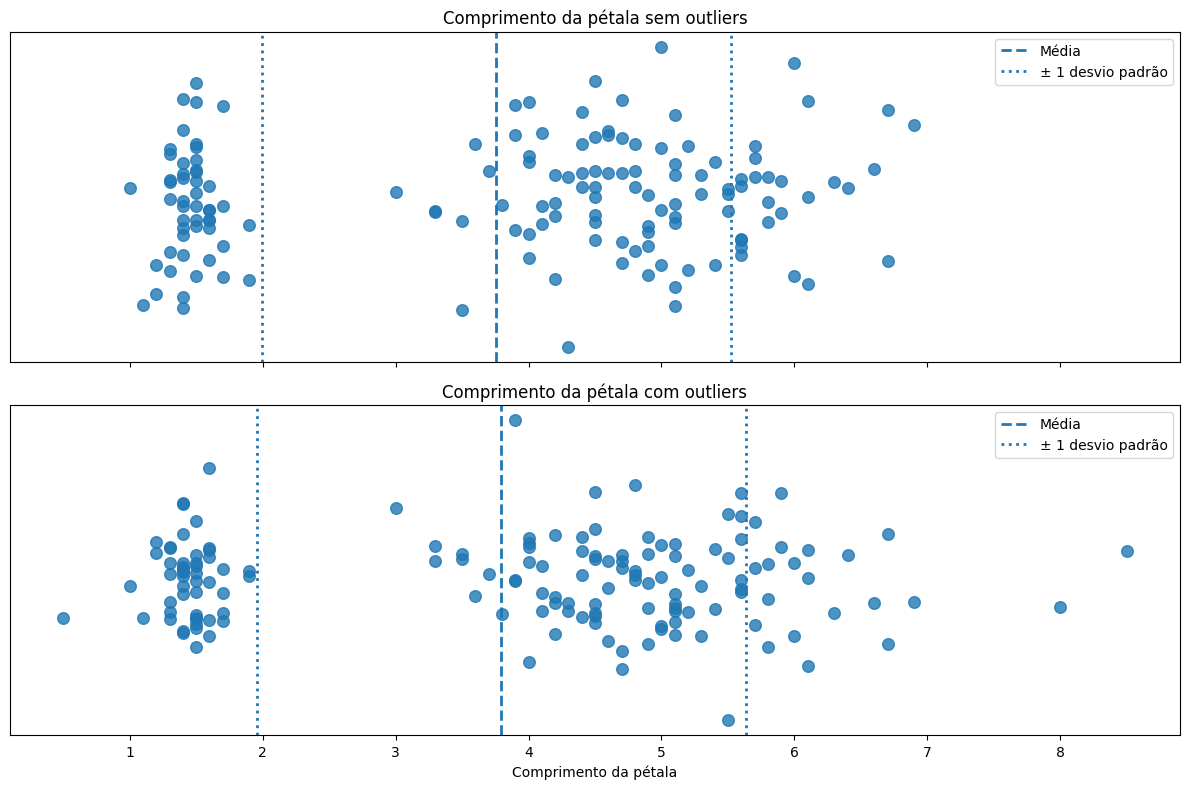

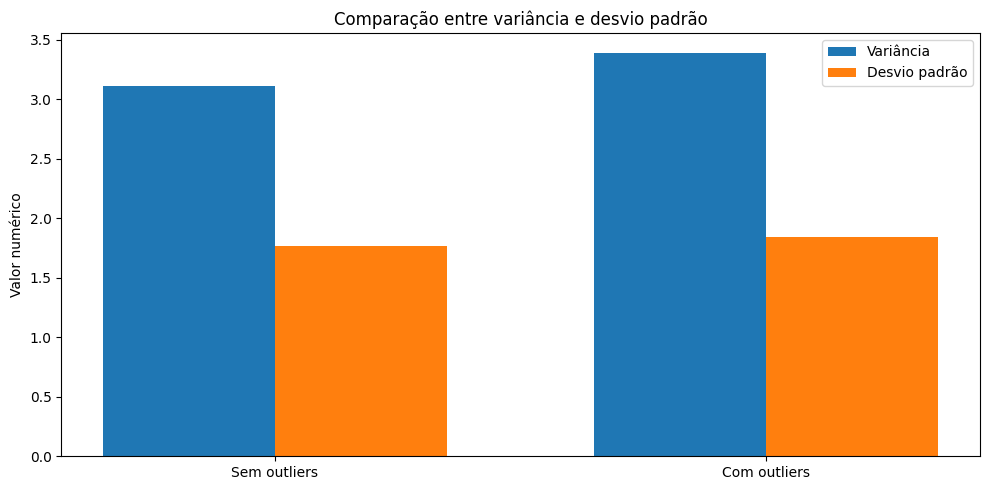

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ============================================================
# EXEMPLO PRÁTICO: VARIÂNCIA vs DESVIO PADRÃO
# Contexto: comprimento da pétala na base Iris
# ============================================================

np.random.seed(42)

# ------------------------------------------------------------
# 1. Dados sintéticos sem outliers
# ------------------------------------------------------------
# Leitura da base Iris
csv_url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(csv_url)

# Dados da base: comprimento da pétala
tamanhos_normais = df["petal_length"]

# ------------------------------------------------------------
# 2. Dados sintéticos com outliers
# ------------------------------------------------------------
# Adicionando valores anormalmente altos e baixos
outliers = np.array([0.5, 8.0, 8.5])
tamanhos_com_outliers = np.concatenate([tamanhos_normais, outliers])

# ------------------------------------------------------------
# 3. Função para calcular medidas
# ------------------------------------------------------------
def resumir_medidas(nome, dados):
    media = np.mean(dados)
    variancia = np.var(dados, ddof=1)
    desvio_padrao = np.std(dados, ddof=1)

    print(f"\n{nome}")
    print("-" * len(nome))
    print(f"Número de observações : {len(dados)}")
    print(f"Média                 : {media:.2f}")
    print(f"Variância             : {variancia:.2f}")
    print(f"Desvio padrão         : {desvio_padrao:.2f}")

# ------------------------------------------------------------
# 4. Resultados numéricos
# ------------------------------------------------------------
resumir_medidas("Sem outliers", tamanhos_normais)
resumir_medidas("Com outliers", tamanhos_com_outliers)

print("\nINTERPRETAÇÃO")
print("A variância é mais sensível a valores extremos.")
print("O desvio padrão é a raiz quadrada da variância.")
print("Como os outliers aumentam os desvios em relação à média, as duas medidas crescem.")
print("Isso mostra como valores extremos afetam a dispersão dos dados.")

# ------------------------------------------------------------
# 5. Visualização
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Gráfico 1: dados sem outliers
y1 = np.random.normal(loc=0, scale=0.04, size=len(tamanhos_normais))
axes[0].scatter(tamanhos_normais, y1, s=70, alpha=0.8)
axes[0].axvline(np.mean(tamanhos_normais), linestyle="--", linewidth=2, label="Média")
axes[0].axvline(np.mean(tamanhos_normais) - np.std(tamanhos_normais, ddof=1),
                linestyle=":", linewidth=2, label="± 1 desvio padrão")
axes[0].axvline(np.mean(tamanhos_normais) + np.std(tamanhos_normais, ddof=1),
                linestyle=":", linewidth=2)
axes[0].set_title("Comprimento da pétala sem outliers")
axes[0].set_yticks([])
axes[0].legend()

# Gráfico 2: dados com outliers
y2 = np.random.normal(loc=0, scale=0.04, size=len(tamanhos_com_outliers))
axes[1].scatter(tamanhos_com_outliers, y2, s=70, alpha=0.8)
axes[1].axvline(np.mean(tamanhos_com_outliers), linestyle="--", linewidth=2, label="Média")
axes[1].axvline(np.mean(tamanhos_com_outliers) - np.std(tamanhos_com_outliers, ddof=1),
                linestyle=":", linewidth=2, label="± 1 desvio padrão")
axes[1].axvline(np.mean(tamanhos_com_outliers) + np.std(tamanhos_com_outliers, ddof=1),
                linestyle=":", linewidth=2)
axes[1].set_title("Comprimento da pétala com outliers")
axes[1].set_yticks([])
axes[1].legend()

plt.xlabel("Comprimento da pétala")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 6. Comparação lado a lado das medidas
# ------------------------------------------------------------
var_sem = np.var(tamanhos_normais, ddof=1)
dp_sem = np.std(tamanhos_normais, ddof=1)

var_com = np.var(tamanhos_com_outliers, ddof=1)
dp_com = np.std(tamanhos_com_outliers, ddof=1)

labels = ["Sem outliers", "Com outliers"]
variancias = [var_sem, var_com]
desvios = [dp_sem, dp_com]

x = np.arange(len(labels))
largura = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - largura/2, variancias, largura, label="Variância")
plt.bar(x + largura/2, desvios, largura, label="Desvio padrão")
plt.xticks(x, labels)
plt.title("Comparação entre variância e desvio padrão")
plt.ylabel("Valor numérico")
plt.legend()
plt.tight_layout()
plt.show()


Cenário 1 - Largura da pétala normal
Número de observações : 150
Média                 : 1.199
Mediana               : 1.300
ADD                   : 0.658
MAD                   : 0.700
Q1                    : 0.300
Q3                    : 1.800
IQR                   : 1.500
Limite inferior       : -1.950
Limite superior       : 4.050
Nenhum outlier detectado pelo critério do boxplot.

Cenário 2 - Largura da pétala com outliers
Número de observações : 154
Média                 : 1.227
Mediana               : 1.300
ADD                   : 0.680
MAD                   : 0.700
Q1                    : 0.300
Q3                    : 1.800
IQR                   : 1.500
Limite inferior       : -1.950
Limite superior       : 4.050
Nenhum outlier detectado pelo critério do boxplot.

INTERPRETAÇÃO
O ADD usa a média como centro e tira a média dos desvios absolutos.
Como a média é sensível a valores extremos, o ADD tende a aumentar mais quando há outliers.

O MAD usa a mediana como centro e tira a m

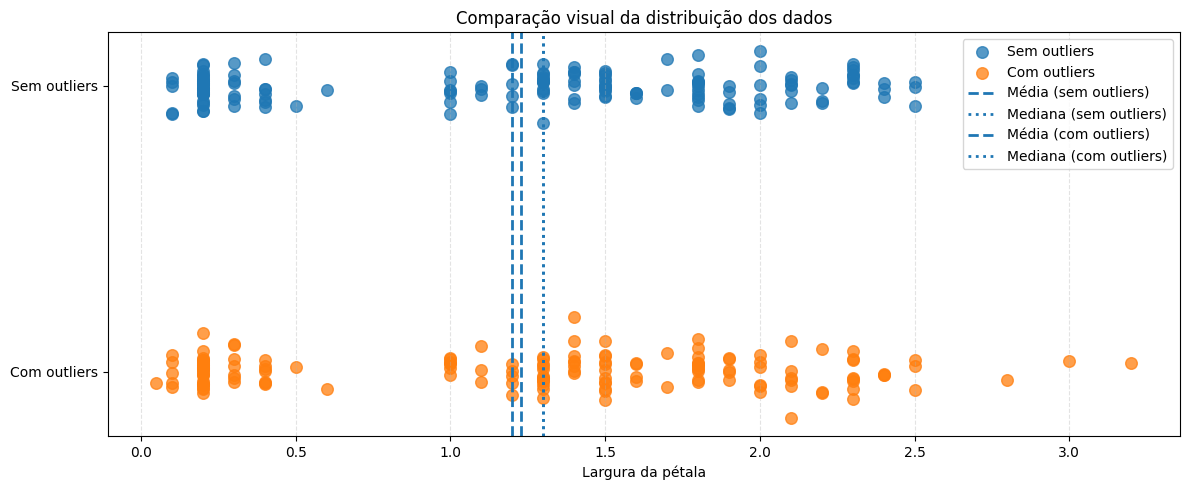

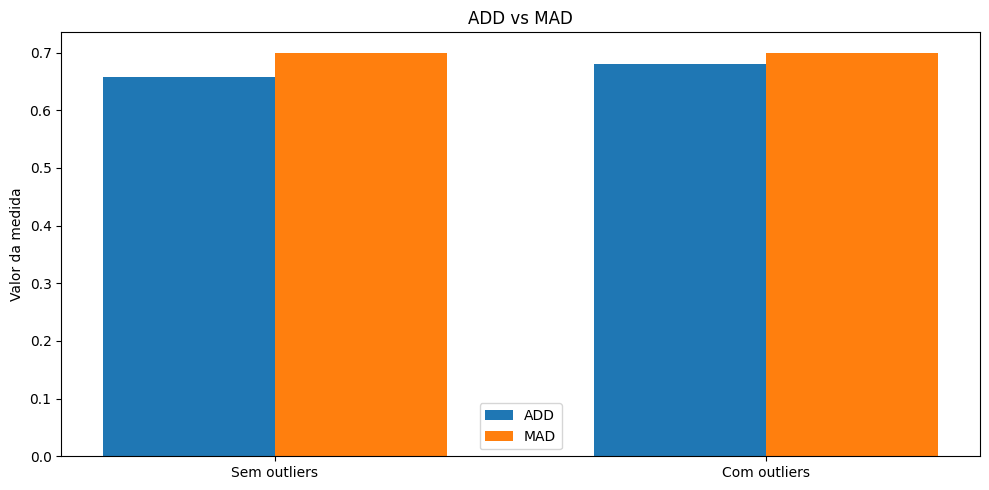

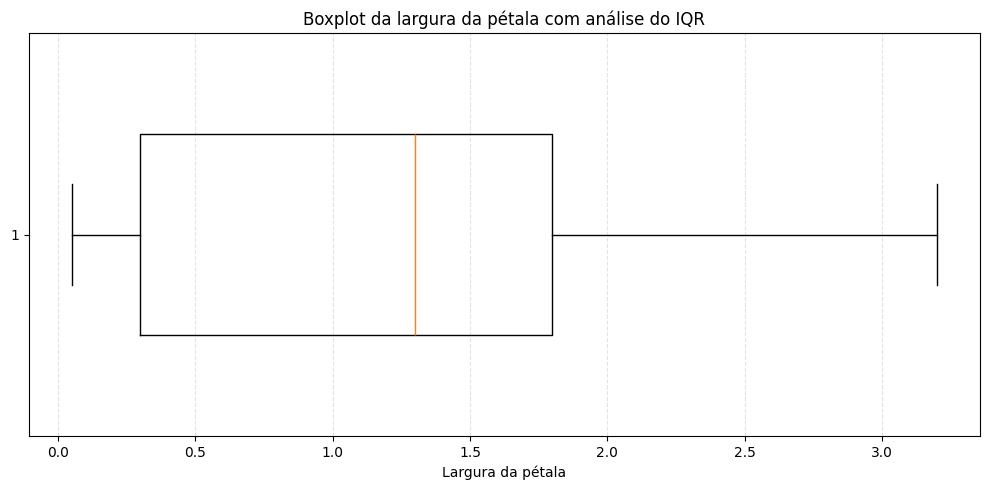


COMENTÁRIO FINAL
Neste exemplo, a presença de outliers aumentou mais o ADD do que o MAD.
Isso reforça que o MAD é mais robusto a valores extremos.


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ============================================================
# EXEMPLO PRÁTICO: ADD vs MAD + análise do IQR com boxplot
# Contexto:
# Largura da pétala medida na base Iris
# ============================================================

np.random.seed(42)

# ------------------------------------------------------------
# 1. Geração dos dados
# ------------------------------------------------------------
# Cenário normal: valores reais da base Iris
csv_url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(csv_url)

petala_normal = df["petal_width"]

# Adicionando alguns outliers
outliers = np.array([0.05, 2.8, 3.0, 3.2])

# Base com outliers
petala_com_outliers = np.concatenate([petala_normal, outliers])


# ------------------------------------------------------------
# 2. Funções de cálculo
# ------------------------------------------------------------
def calcular_add(dados):
    """
    ADD = Average Absolute Deviation em torno da média
    """
    media = np.mean(dados)
    return np.mean(np.abs(dados - media))


def calcular_mad(dados):
    """
    MAD = Median Absolute Deviation em torno da mediana
    """
    mediana = np.median(dados)
    return np.median(np.abs(dados - mediana))


def resumo_medidas(nome, dados):
    media = np.mean(dados)
    mediana = np.median(dados)
    add = calcular_add(dados)
    mad = calcular_mad(dados)

    q1 = np.percentile(dados, 25)
    q3 = np.percentile(dados, 75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    outliers_detectados = dados[(dados < limite_inferior) | (dados > limite_superior)]

    print("\n" + "=" * 70)
    print(nome)
    print("=" * 70)
    print(f"Número de observações : {len(dados)}")
    print(f"Média                 : {media:.3f}")
    print(f"Mediana               : {mediana:.3f}")
    print(f"ADD                   : {add:.3f}")
    print(f"MAD                   : {mad:.3f}")
    print(f"Q1                    : {q1:.3f}")
    print(f"Q3                    : {q3:.3f}")
    print(f"IQR                   : {iqr:.3f}")
    print(f"Limite inferior       : {limite_inferior:.3f}")
    print(f"Limite superior       : {limite_superior:.3f}")

    if len(outliers_detectados) > 0:
        print("Outliers pelo critério do boxplot:")
        print(np.round(np.sort(outliers_detectados), 3))
    else:
        print("Nenhum outlier detectado pelo critério do boxplot.")

    return {
        "media": media,
        "mediana": mediana,
        "add": add,
        "mad": mad,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "lim_inf": limite_inferior,
        "lim_sup": limite_superior,
        "outliers": outliers_detectados
    }


# ------------------------------------------------------------
# 3. Resumo numérico
# ------------------------------------------------------------
res_normal = resumo_medidas("Cenário 1 - Largura da pétala normal", petala_normal)
res_out = resumo_medidas("Cenário 2 - Largura da pétala com outliers", petala_com_outliers)

print("\n" + "=" * 70)
print("INTERPRETAÇÃO")
print("=" * 70)
print(
    "O ADD usa a média como centro e tira a média dos desvios absolutos.\n"
    "Como a média é sensível a valores extremos, o ADD tende a aumentar mais quando há outliers."
)
print()
print(
    "O MAD usa a mediana como centro e tira a mediana dos desvios absolutos.\n"
    "Como a mediana é robusta, o MAD tende a sofrer menos com outliers."
)
print()
print(
    "O IQR mede a dispersão dos 50% centrais dos dados (Q3 - Q1),\n"
    "sendo também uma medida robusta. No boxplot, pontos fora dos limites\n"
    "Q1 - 1.5*IQR e Q3 + 1.5*IQR aparecem como possíveis outliers."
)


# ------------------------------------------------------------
# 4. Gráfico 1: distribuição dos pontos
# ------------------------------------------------------------
y1 = np.random.normal(loc=1.0, scale=0.05, size=len(petala_normal))
y2 = np.random.normal(loc=0.0, scale=0.05, size=len(petala_com_outliers))

plt.figure(figsize=(12, 5))
plt.scatter(petala_normal, y1, s=70, alpha=0.75, label="Sem outliers")
plt.scatter(petala_com_outliers, y2, s=70, alpha=0.75, label="Com outliers")

plt.axvline(res_normal["media"], linestyle="--", linewidth=2, label="Média (sem outliers)")
plt.axvline(res_normal["mediana"], linestyle=":", linewidth=2, label="Mediana (sem outliers)")

plt.axvline(res_out["media"], linestyle="--", linewidth=2, label="Média (com outliers)")
plt.axvline(res_out["mediana"], linestyle=":", linewidth=2, label="Mediana (com outliers)")

plt.yticks([0, 1], ["Com outliers", "Sem outliers"])
plt.xlabel("Largura da pétala")
plt.title("Comparação visual da distribuição dos dados")
plt.grid(axis="x", linestyle="--", alpha=0.35)
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. Gráfico 2: comparação entre ADD e MAD
# ------------------------------------------------------------
labels = ["Sem outliers", "Com outliers"]
valores_add = [res_normal["add"], res_out["add"]]
valores_mad = [res_normal["mad"], res_out["mad"]]

x = np.arange(len(labels))
largura = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - largura / 2, valores_add, largura, label="ADD")
plt.bar(x + largura / 2, valores_mad, largura, label="MAD")
plt.xticks(x, labels)
plt.ylabel("Valor da medida")
plt.title("ADD vs MAD")
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6. Gráfico 3: boxplot para análise do IQR
# ------------------------------------------------------------
plt.figure(figsize=(10, 5))
plt.boxplot(
    petala_com_outliers,
    vert=False,
    widths=0.5,
    patch_artist=False,
    whis=1.5
)
plt.xlabel("Largura da pétala")
plt.title("Boxplot da largura da pétala com análise do IQR")
plt.grid(axis="x", linestyle="--", alpha=0.35)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 7. Comentário final programático
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("COMENTÁRIO FINAL")
print("=" * 70)

if res_out["add"] - res_normal["add"] > res_out["mad"] - res_normal["mad"]:
    print(
        "Neste exemplo, a presença de outliers aumentou mais o ADD do que o MAD.\n"
        "Isso reforça que o MAD é mais robusto a valores extremos."
    )
else:
    print(
        "Neste exemplo, o impacto dos outliers foi semelhante nas duas medidas,\n"
        "mas, em geral, o MAD tende a ser mais robusto que o ADD."
    )